# Context:
AZ Tunes is a music streaming company that analyzes customer data to improve recommendations, and playlists, and roll out special offers. Their persistent work to uncover and act upon evolving customer expectations has resulted in higher customer engagement time and subscription to their paid service.



# Objective:
- The Marketing team of AZ Tunes wants to roll out special offers through a new campaign. As a data scientist, your objective is to help the team design the campaign by providing the below data-driven inputs:

- According to a study, the average weekly app engagement time of users in leading music services is around 6 hrs. Can we claim that the app engagement time of AZ tunes is better than this market standard?
The team wants to spend its budget on the age group that has the highest chance of subscribing as part of its campaign.

- You need to perform statistical analysis on a sample of customer data and provide an evidence-based conclusion to help the marketing campaign succeed.



# Data Description:
- The az_tunes.csv file contains the following information:

    - user_id: Unique user-id of the user
    - age_group: Age-group that the user belongs to
    - subscription_status: Whether the user is a subscribed user or a non-subscribed user
    - enagement_time: Weekly average of app engagement time (in hrs) of the user

# Solution Approach

 - to solve problem we need answer of 2 questions

     -  is the average engagement time of AZ tunes is greater than market average(6 hrs).

     - is th different proportion of subscriber and non subscribers (in 3 groups on basis age , under 18 , 18-34 and over 35) significantly different to conclude that particular group is mostly likely subscribe.

In [ ]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats  as stats

#### load dataset

In [ ]:
df = pd.read_csv("az_tunes.csv")

#### data overview

In [ ]:
df.head()

,user_id,age_group,subscription_status,engagement_time
0,14451,18-34,subscribed,5.55
1,18386,under 18,subscribed,5.12
2,12305,35 and over,not_subscribed,4.25
3,17546,18-34,subscribed,8.54
4,15399,18-34,subscribed,12.12


##### check  shape and data type of columns

In [ ]:
df.shape

(1000, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              1000 non-null   int64  
 1   age_group            1000 non-null   object 
 2   subscription_status  1000 non-null   object 
 3   engagement_time      1000 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB


#### check missing values

In [ ]:
df.isna().sum()

,0
user_id,0
age_group,0
subscription_status,0
engagement_time,0


- no missing value

##### statistical summary of dataset

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,1000.0,15024.80300,2927.044957,10000.00,12452.5000,15184.0,17481.25,19976.00
engagement_time,1000.0,6.18003,2.757166,0.22,3.9175,6.0,8.11,16.98


# T test

  -  it is a statistical hypothesis test used to determine whether there is sginificant difference between means  when

    - 1.  the sample size is small less than 30 .
    - 2 . the population std is unknown
    - one sample t test
         -  used to compare mean with known or claimed population mean.

    - independent two sample t test
         - used to compare the means of two independent groups


# Next step  Find the P value

    -   degree of freedom  df  = n -1
    -  degree of freedom represent the no of values in calculation that are free to vary after constraints are applied.

#### One Sample t test

-  Is the average app engagement of AZ tunes  is greater than the market average (6 hrs)

sample mean 6.0 2


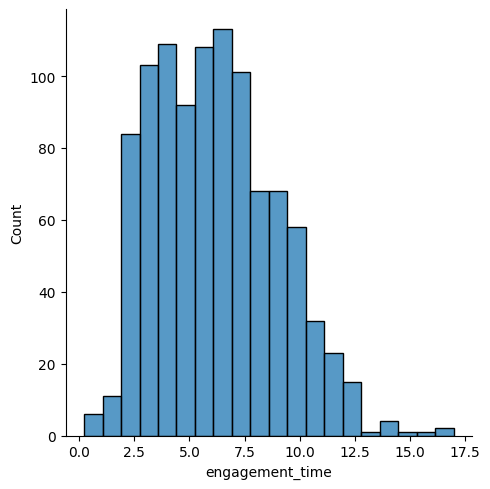

In [ ]:
print("sample mean",np.round(df.engagement_time.mean()),2)
sns.displot(df.engagement_time)


# Step 1 Define null and alternate hypothesis

 - Ho   :  the mean app engagement time is less or equal to 6 hrs.
 - H1   :  the mean app engagement time is grater than 6 hrs

 -   Ho  :  mu <= 6
 -  H1   : mu > 6

# Step 2 :  Select appropriate test   
   - one sample t test

# Step 3: Decide the significance level  

 - alpha  = 0.05

# Step 4:  Calculate the p value

In [ ]:
hyp_mean=6
t_stat , p_value =stats.ttest_1samp(df['engagement_time'],hyp_mean, alternative="greater") # alternative argument is used to specify the tail of test
print(" test stats",t_stat)
print('p-value',p_value)

 test stats 2.0648187232381248
p-value 0.019598877431817586


# Step 5 : compare the p value with alpha

In [ ]:
if p_value < 0.05:
  print (f' as the p value {p_value} is less than the level of significance , we reject the null hypothesis')
else:
   print (f' as the p value {p_value} is greater than the level of significance , we  fail to reject the null hypothesis')

 as the p value 0.019598877431817586 is less than the level of significance , we reject the null hypothesis
